In [12]:
# CNN Image Classification: MNIST & Fashion-MNIST

# Objective: Build a Convolutional Neural Network (CNN) using PyTorch for image classification and investigate how the number of convolutional filters affects model performance.

# Workflow:
# 1. Load and preprocess MNIST
# 2. Build a CNN
# 3. Train and evaluate the model
# 4. Analyze the effect of convolutional filter count
# 5. Select the best configuration
# 6. Apply the selected architecture to Fashion-MNIST
# 7. Compare classification performance

In [13]:
import torch                                        #importing PyTorch
import torch.nn as nn                               #importing neural networks
import torch.optim as optim                         #importing optimizers
import torchvision                                  #importing datasets
import torchvision.transforms as transforms         #importing for preprocessing the data
import matplotlib.pyplot as plt
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")    #if gpu available then use cuda else use cpu

In [14]:
# 1. Dataset Preparation: MNIST dataset

# MNIST contains grayscale images of handwritten digits from 0–9.
# Each image is 28 × 28 pixels and belongs to one of 10 classes.

In [15]:
# Data
transform = transforms.ToTensor()     #to transform data images into tensors for PyTorch

#transform the train and train datsets and auto-download if not available
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)

#split both the datasets into batches of size 64
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True) #shuffle the training dataset
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)  #don't shuffle the test data

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Training samples: 60000
Test samples: 10000


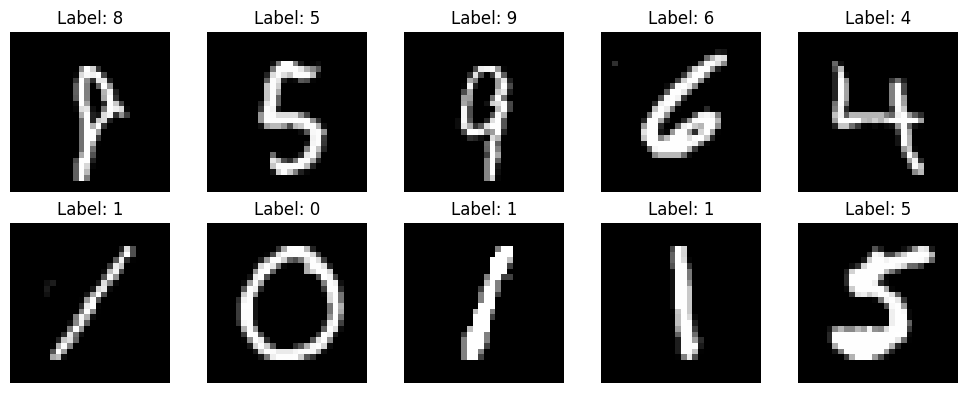

In [16]:
#MNIST data visualization:
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap="gray")
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [17]:
# 2. CNN Architecture:

# The CNN consists of:
# - Two convolutional layers
# - ReLU activation
# - Max pooling after each convolution
# - Fully connected layers
# - 10 output neurons corresponding to digits 0–9

# The number of filters in the convolutional layers is treated as a hyperparameter.

In [18]:
#creating a neural network class:
class CNN(nn.Module):
    def __init__(self, num_filters=16):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, num_filters, kernel_size=3, padding=1)   #creating convolutional layer that will recognize the edges of the digits
        self.conv2 = nn.Conv2d(num_filters, num_filters*2, kernel_size=3, padding=1) #this layer will recognize the shape of the digits

        self.pool = nn.MaxPool2d(2, 2)  #reduce image size by half

        self.fc1 = nn.Linear((num_filters*2)*7*7, 128) #process the extracted features
        self.fc2 = nn.Linear(128, 10)  #gives the final answer

        self.relu = nn.ReLU()  #adds non-linearity to understand complex patterns

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x))) #applying first set of conv -> relu-> pool
        x = self.pool(self.relu(self.conv2(x))) #applying second set of conv -> relu -> pool

        x = x.view(x.size(0), -1) #converts 2D image to 1D array of numbers

        x = self.relu(self.fc1(x)) #process all extracted features
        x = self.fc2(x) #score all the digits 0-9 predicted according to the model accuracy & the digit with highest accuracy score will be our final answer

        return x

In [19]:
#defining training model:
def train_model(model, train_loader, test_loader, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_acc_list = []
    test_acc_list = []

    for epoch in range(epochs):

        # Training
        model.train()
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
        train_acc = correct / total
        train_acc_list.append(train_acc)

        # Testing
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():

            for images, labels in test_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                _, predicted = torch.max(outputs, 1)

                correct += (predicted == labels).sum().item()
                total += labels.size(0)
        test_acc = correct / total
        test_acc_list.append(test_acc)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Accuracy: {train_acc:.4f} | "
            f"Test Accuracy: {test_acc:.4f}")
    return train_acc_list, test_acc_list

In [20]:
model = CNN(num_filters=16).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal parameters: {total_params:,}")

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)

Total parameters: 206,922


In [21]:
# 3. Model Training:

# The model is trained using:
# - Cross-Entropy Loss
# - Adam optimizer
# - Learning rate = 0.001
# - Batch size = 64
# - 5 training epochs

Epoch 1/5 | Train Accuracy: 0.9342 | Test Accuracy: 0.9800
Epoch 2/5 | Train Accuracy: 0.9826 | Test Accuracy: 0.9860
Epoch 3/5 | Train Accuracy: 0.9875 | Test Accuracy: 0.9881
Epoch 4/5 | Train Accuracy: 0.9903 | Test Accuracy: 0.9886
Epoch 5/5 | Train Accuracy: 0.9922 | Test Accuracy: 0.9885


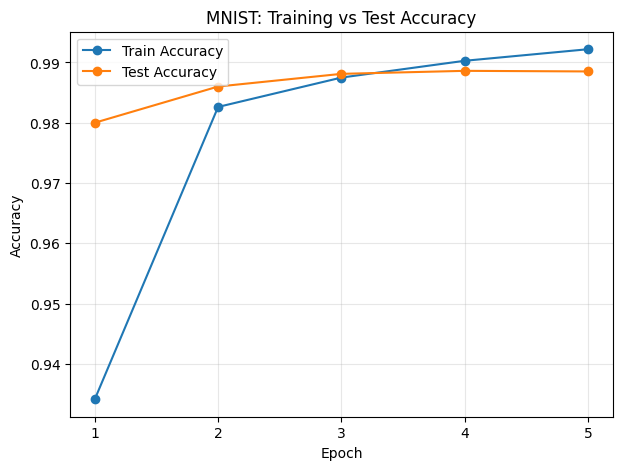

In [22]:
#training CNN model
model = CNN(num_filters=16).to(device)
train_acc, test_acc = train_model(model, train_loader, test_loader, epochs=5)
epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs, train_acc, marker="o", label="Train Accuracy")
plt.plot(epochs, test_acc, marker="o",label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MNIST: Training vs Test Accuracy")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [23]:
# 4. Effect of Number of Convolutional Filters: The number of convolutional filters controls how many feature maps are learned by the CNN.

# We compare models using:
# - 8 filters
# - 16 filters
# - 32 filters
# The final test accuracy is recorded for each configuration.

In [24]:
#testing by filter count
filters_list = [8, 16, 32]
accuracy_results = []

for f in filters_list:
    print(f"\nTraining CNN with {f} filters")
    model = CNN(num_filters=f).to(device)
    _, test_acc = train_model(
        model,
        train_loader,
        test_loader,
        epochs=3)
    accuracy_results.append(test_acc[-1])


Training CNN with 8 filters
Epoch 1/3 | Train Accuracy: 0.9024 | Test Accuracy: 0.9686
Epoch 2/3 | Train Accuracy: 0.9730 | Test Accuracy: 0.9814
Epoch 3/3 | Train Accuracy: 0.9813 | Test Accuracy: 0.9854

Training CNN with 16 filters
Epoch 1/3 | Train Accuracy: 0.9304 | Test Accuracy: 0.9793
Epoch 2/3 | Train Accuracy: 0.9806 | Test Accuracy: 0.9848
Epoch 3/3 | Train Accuracy: 0.9860 | Test Accuracy: 0.9902

Training CNN with 32 filters
Epoch 1/3 | Train Accuracy: 0.9444 | Test Accuracy: 0.9796
Epoch 2/3 | Train Accuracy: 0.9835 | Test Accuracy: 0.9859
Epoch 3/3 | Train Accuracy: 0.9887 | Test Accuracy: 0.9876


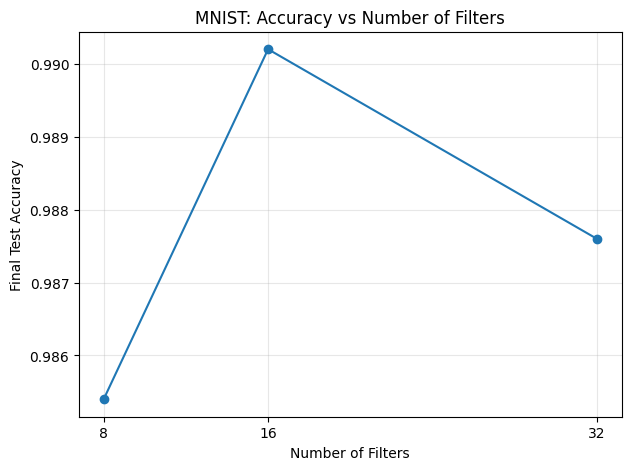

In [25]:
plt.figure(figsize=(7, 5))
plt.plot(filters_list, accuracy_results, marker="o")
plt.xlabel("Number of Filters")
plt.ylabel("Final Test Accuracy")
plt.title("MNIST: Accuracy vs Number of Filters")
plt.xticks(filters_list)
plt.grid(alpha=0.3)

plt.show()

In [26]:
#filter comparison:
results = pd.DataFrame({"Number of Filters": filters_list,"Final Test Accuracy": accuracy_results})
results["Final Test Accuracy (%)"] = (results["Final Test Accuracy"] * 100).round(2)
results

,Number of Filters,Final Test Accuracy,Final Test Accuracy (%)
0,8,0.9854,98.54
1,16,0.9902,99.02
2,32,0.9876,98.76


In [27]:
#best selected filter
best_filters = filters_list[
    accuracy_results.index(max(accuracy_results))]
best_accuracy = max(accuracy_results)

print(f"Selected filter configuration: {best_filters}")
print(f"Test accuracy: {best_accuracy:.2%}")

Selected filter configuration: 16
Test accuracy: 99.02%


In [28]:
# 5. Fashion-MNIST Classification:
# The selected CNN architecture is now applied to Fashion-MNIST.
# Fashion-MNIST contains 10 classes of clothing images, providing a more challenging classification task than handwritten digits.

In [29]:
# download Fashion-MNIST train and test datasets
fashion_train = torchvision.datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
fashion_test = torchvision.datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

# download Fashion-MNIST train and test datasets
fashion_train_loader = torch.utils.data.DataLoader(fashion_train, batch_size=64, shuffle=True)
fashion_test_loader = torch.utils.data.DataLoader(fashion_test, batch_size=64, shuffle=False)
print("Fashion-MNIST training samples:", len(fashion_train))
print("Fashion-MNIST test samples:", len(fashion_test))

100%|██████████| 26.4M/26.4M [00:01<00:00, 15.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 229kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.24MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.85MB/s]

Fashion-MNIST training samples: 60000
Fashion-MNIST test samples: 10000


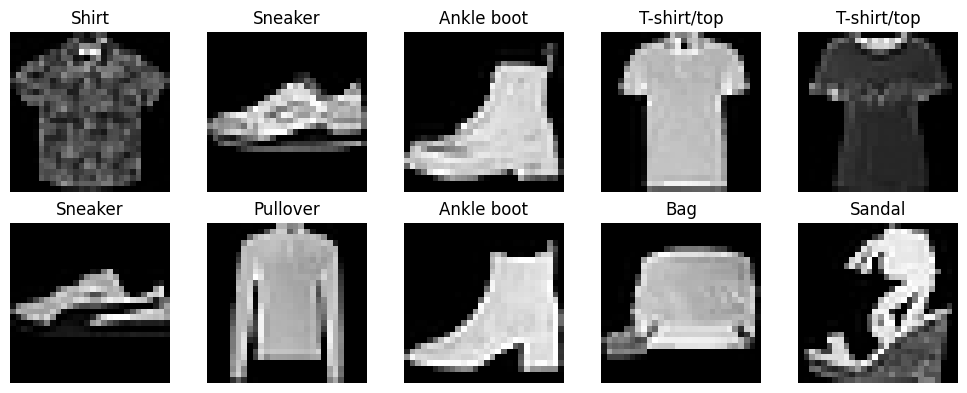

In [30]:
#visualizing FMNIST dataset
images, labels = next(iter(fashion_train_loader))
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat","Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap="gray")
    ax.set_title(class_names[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [31]:
#applying model to FMNIST dataset
fashion_model = CNN(num_filters=best_filters).to(device)

f_train_acc, f_test_acc = train_model(
    fashion_model,
    fashion_train_loader,
    fashion_test_loader,
    epochs=5)

Epoch 1/5 | Train Accuracy: 0.8187 | Test Accuracy: 0.8670
Epoch 2/5 | Train Accuracy: 0.8821 | Test Accuracy: 0.8821
Epoch 3/5 | Train Accuracy: 0.8964 | Test Accuracy: 0.8737
Epoch 4/5 | Train Accuracy: 0.9079 | Test Accuracy: 0.9002
Epoch 5/5 | Train Accuracy: 0.9146 | Test Accuracy: 0.9071


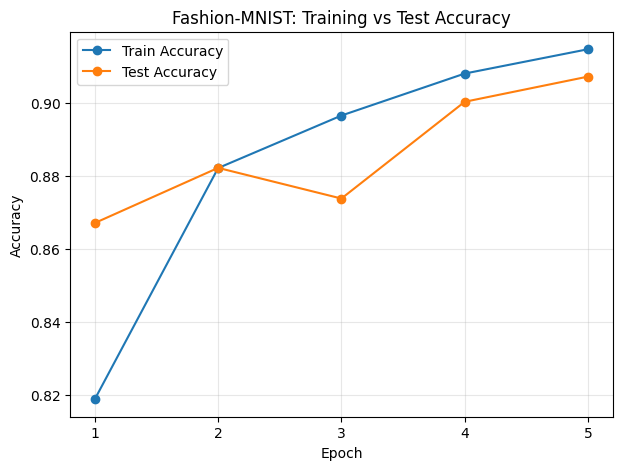

In [32]:
#FMNIST accuracy plot
epochs = range(1, len(f_train_acc) + 1)
plt.figure(figsize=(7, 5))
plt.plot(epochs, f_train_acc, marker="o", label="Train Accuracy")
plt.plot(epochs, f_test_acc, marker="o", label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Fashion-MNIST: Training vs Test Accuracy")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [33]:
final_results = pd.DataFrame({"Dataset": ["MNIST", "Fashion-MNIST"],"Test Accuracy": [max(test_acc),max(f_test_acc)]})
final_results["Test Accuracy (%)"] = (final_results["Test Accuracy"] * 100).round(2)
final_results

,Dataset,Test Accuracy,Test Accuracy (%)
0,MNIST,0.9876,98.76
1,Fashion-MNIST,0.9071,90.71


In [34]:
# 6. Conclusion:
# A PyTorch CNN was developed for image classification on MNIST and Fashion-MNIST.
# The experiment investigated the effect of convolutional filter count by comparing 8, 16, and 32 filters.

# Key Takeaways:
# - Increasing model capacity changes classification performance.
# - The same CNN architecture can be adapted to different 10-class grayscale image datasets.
# - Fashion-MNIST provides a more challenging classification task than handwritten digit recognition.